# 01 - Compreensão do Problema e Análise Exploratória (EDA)

**Tech Challenge Fase 2 - POSTECH Data Analytics**

Objetivo: prever a qualidade de um vinho a partir de suas características
físico-químicas, tratando o problema como uma **classificação binária**:

- **Alta Qualidade**: nota (`quality`) >= 7
- **Baixa/Média Qualidade**: nota < 7

Dataset: [Wine Quality Dataset](https://archive.ics.uci.edu/dataset/186/wine+quality)
(UCI/Kaggle), combinando as amostras de vinho tinto e branco em uma única base,
com uma coluna adicional `wine_type` indicando a origem.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from data_loader import load_dataset

sns.set_theme(style="whitegrid")
RESULTS = "../results"

df = load_dataset()
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,wine_type,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0


## Estrutura do dataset

6.497 amostras (1.599 tintos + 4.898 brancos), 11 variáveis físico-químicas
preditoras, mais `wine_type` (engenharia de feature), `quality` (nota original)
e `high_quality` (target binário).

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
 13  high_quality          6497 non-null   int64  
dtypes: float64(11), int64(2), str(1)
memory usage: 710.7 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## Qualidade da entrada: nulos e duplicatas

Não há valores faltantes no dataset. Há, no entanto, **1.177 linhas duplicadas
(18,1% da base)** - um efeito conhecido deste dataset: como as variáveis são
medidas físico-químicas arredondadas em poucas casas decimais, diferentes
amostras acabam colidindo no mesmo perfil de valores. Essas duplicatas serão
removidas **antes do split treino/teste** na etapa de pré-processamento
(notebook 02), para evitar vazamento de dados (a mesma amostra aparecendo em
treino e teste simultaneamente).

In [4]:
print("Valores nulos:", df.isnull().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum(),
      f"({df.duplicated().mean()*100:.1f}%)")

Valores nulos: 0
Linhas duplicadas: 1177 (18.1%)


## Da nota original à classificação binária

A nota de qualidade concentra-se fortemente entre 5 e 7 (formato aproximadamente
normal, com poucas amostras nos extremos 3, 4, 8 e 9). Ao aplicar o corte em
`quality >= 7`, obtemos:

- **19,7%** das amostras como Alta Qualidade
- **80,3%** como Baixa/Média Qualidade

Ou seja, um desbalanceamento de aproximadamente **1 para 4**. Isso tem duas
implicações diretas para as próximas etapas:

1. **Métricas**: acurácia isoladamente é enganosa (um modelo trivial que sempre
   prevê "Baixa/Média" já acertaria ~80%). Serão priorizadas recall, precisão,
   F1 e AUC (ROC e Precision-Recall) para a classe minoritária.
2. **Modelagem**: será usado `class_weight="balanced"` (e equivalente via
   `scale_pos_weight` no XGBoost) para compensar o desbalanceamento durante o
   treino.

O desbalanceamento também varia por tipo de vinho: **13,6%** dos tintos são
Alta Qualidade contra **21,6%** dos brancos - um indício de que `wine_type`
pode carregar sinal relevante.

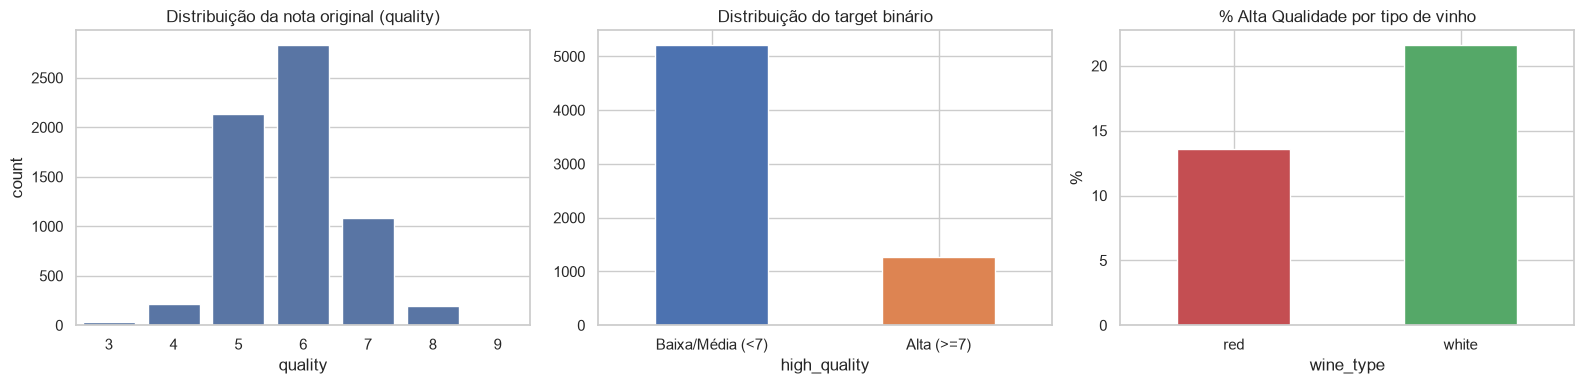

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x="quality", ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição da nota original (quality)")

df["high_quality"].map({0: "Baixa/Média (<7)", 1: "Alta (>=7)"}).value_counts().plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"]
)
axes[1].set_title("Distribuição do target binário")
axes[1].tick_params(axis="x", rotation=0)

df.groupby("wine_type")["high_quality"].mean().mul(100).plot(
    kind="bar", ax=axes[2], color=["#C44E52", "#55A868"]
)
axes[2].set_title("% Alta Qualidade por tipo de vinho")
axes[2].set_ylabel("%")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(f"{RESULTS}/01_target_distribution.png", dpi=150)
plt.show()

## Distribuição das variáveis físico-químicas por classe

Comparando a distribuição de cada variável entre as duas classes, é possível
identificar visualmente quais parecem separar melhor Alta Qualidade de
Baixa/Média Qualidade.

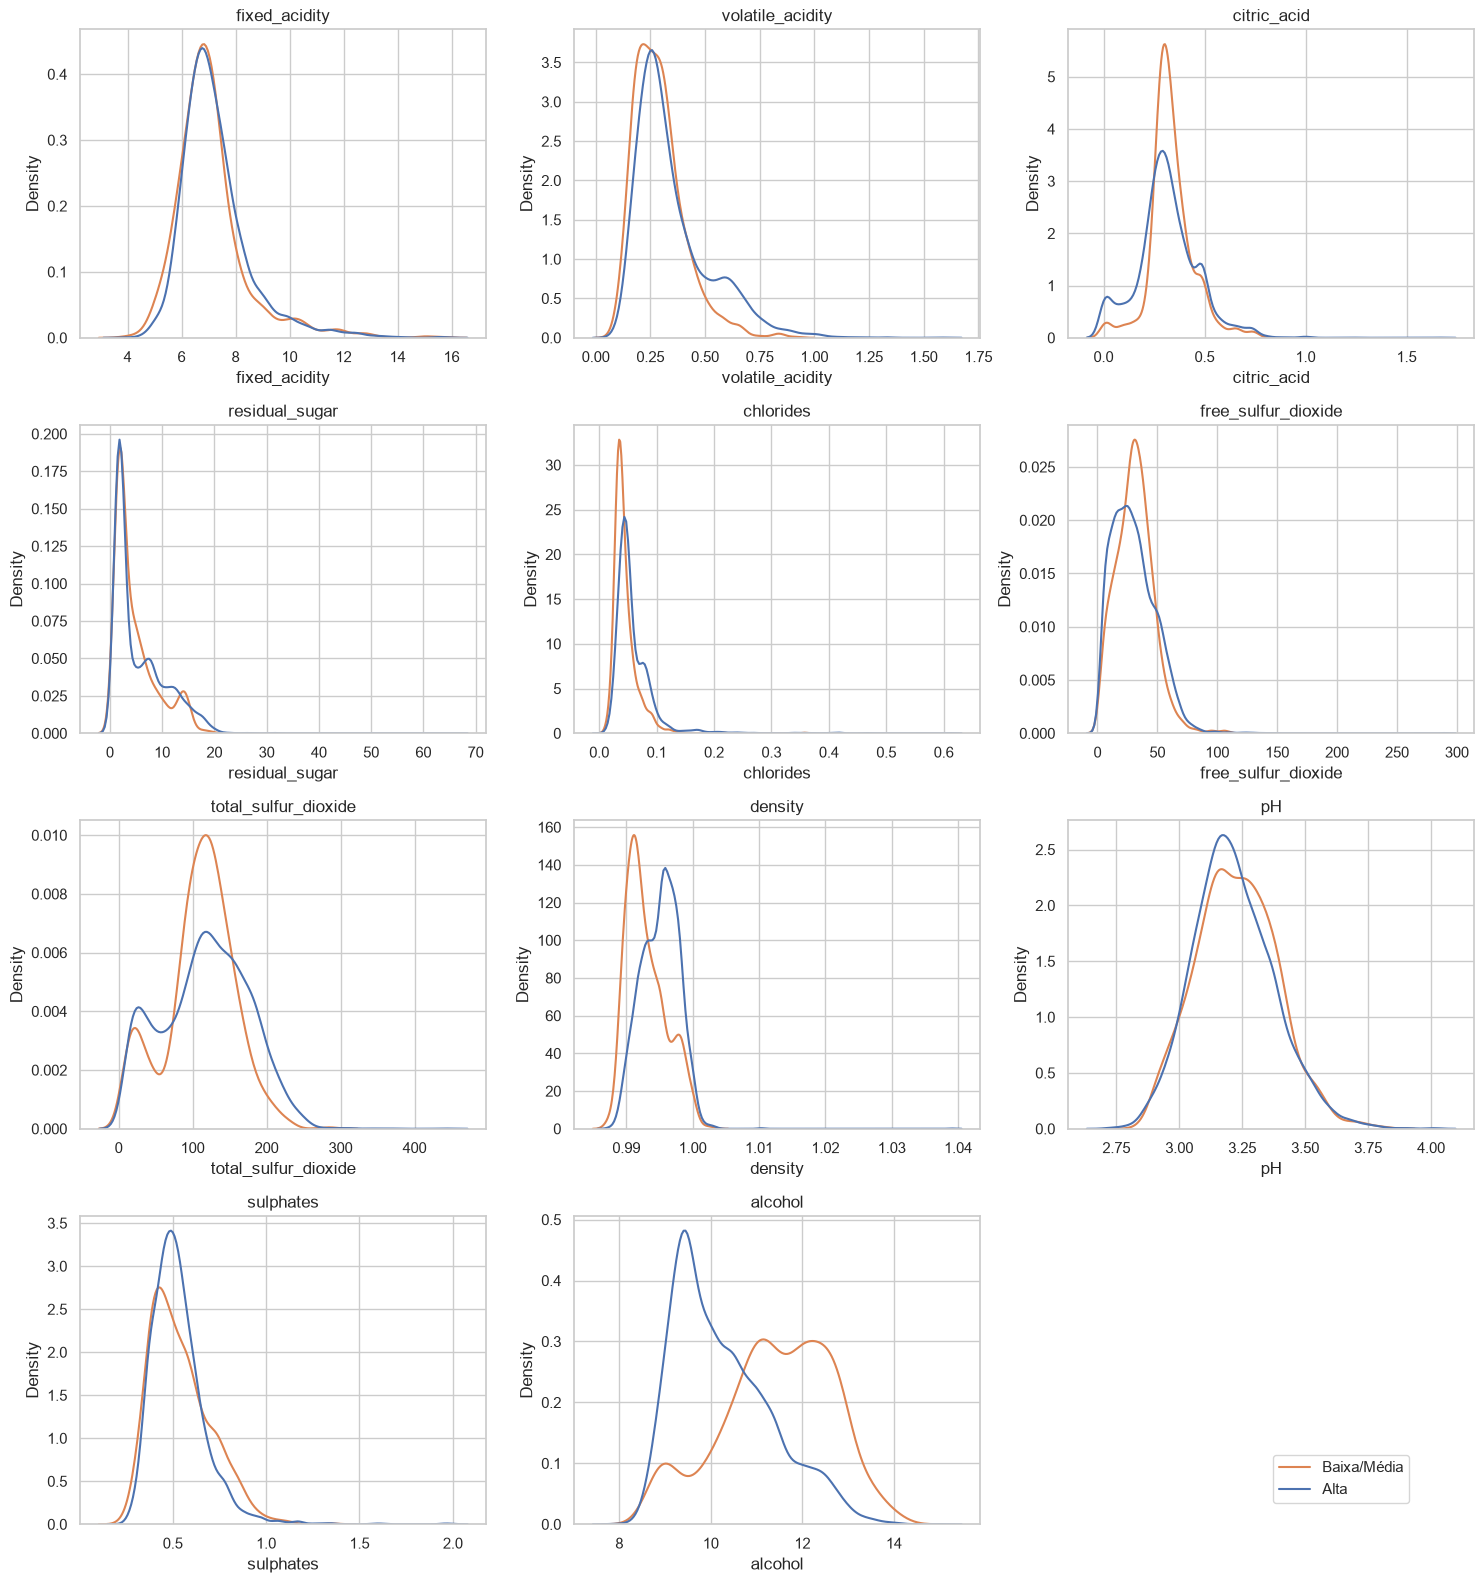

In [6]:
features = [c for c in df.columns if c not in ("quality", "high_quality", "wine_type")]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for ax, col in zip(axes.flat, features):
    sns.kdeplot(data=df, x=col, hue="high_quality", ax=ax, common_norm=False, legend=False)
    ax.set_title(col)
axes.flat[-1].axis("off")
fig.legend(["Baixa/Média", "Alta"], loc="lower right", bbox_to_anchor=(0.95, 0.05))
plt.tight_layout()
plt.savefig(f"{RESULTS}/02_feature_distributions.png", dpi=150)
plt.show()

## Correlações com a qualidade

A tabela abaixo mostra a correlação de Pearson de cada variável com a nota
original (`quality`) e com o target binário (`high_quality`). A leitura é
consistente entre as duas versões da variável alvo, o que reforça que a
binarização não distorce o sinal presente nos dados.

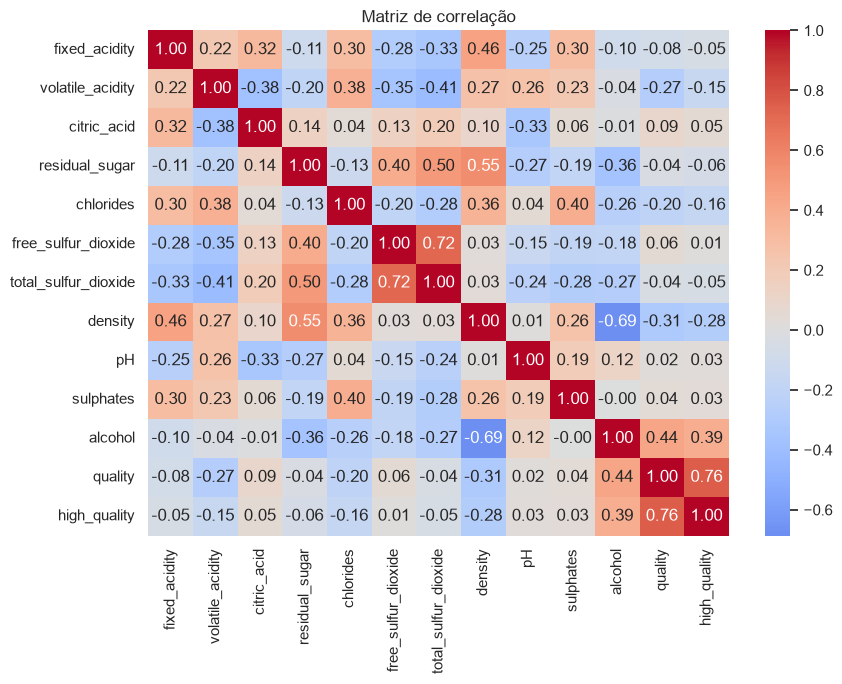

alcohol                 0.390486
density                -0.275441
chlorides              -0.161781
volatile_acidity       -0.151714
residual_sugar         -0.063992
citric_acid             0.054444
total_sulfur_dioxide   -0.051226
fixed_acidity          -0.049447
sulphates               0.033971
pH                      0.028149
free_sulfur_dioxide     0.014767
Name: high_quality, dtype: float64

In [7]:
numeric_cols = [c for c in df.columns if c != "wine_type"]
corr = df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlação")
plt.tight_layout()
plt.savefig(f"{RESULTS}/03_correlation_heatmap.png", dpi=150)
plt.show()

corr["high_quality"].drop(["high_quality", "quality"]).sort_values(key=abs, ascending=False)

### Leitura das correlações (justificativa variável a variável)

- **Álcool (+0,39 com quality / +0,39 com high_quality)**: a correlação mais
  forte da base. Vinhos com maior teor alcoólico tendem a vir de uvas mais
  maduras (mais açúcar convertido em álcool na fermentação), associadas a
  perfis sensoriais mais encorpados e melhor avaliados por especialistas.
- **Densidade (-0,31 / -0,28)**: correlação negativa esperada, pois densidade
  e álcool são inversamente relacionados fisicamente (etanol é menos denso que
  água) - a densidade funciona quase como um proxy invertido do teor alcoólico
  e do açúcar residual.
- **Acidez volátil (-0,27 / -0,15)**: mede principalmente ácido acético,
  associado a defeitos de fermentação (contaminação bacteriana). Quanto maior,
  mais o vinho tende a apresentar aroma de vinagre, reduzindo a nota.
- **Cloretos (-0,20 / -0,16)**: proxy de salinidade/teor mineral da uva;
  concentrações altas geram gosto salgado indesejado, penalizando a avaliação.
- **Ácido cítrico (+0,09 / +0,05)**: correlação positiva fraca; em pequenas
  doses contribui para frescor e equilíbrio ácido, mas o efeito é discreto
  frente às demais variáveis.
- **Dióxido de enxofre livre (+0,06 / +0,01)**: correlação praticamente nula
  isoladamente; seu papel (antioxidante/antimicrobiano) só faz sentido em
  conjunto com o SO2 total, o que motiva a feature de proporção livre/total
  criada no pré-processamento (notebook 02).
- **Sulfatos (+0,04 / +0,03)** e **pH (+0,02 / +0,03)**: correlações lineares
  fracas com o target; podem ainda contribuir em interações não-lineares
  capturadas por modelos baseados em árvore.
- **Acidez fixa (-0,08 / -0,05)**, **SO2 total (-0,04 / -0,05)** e **açúcar
  residual (-0,04 / -0,06)**: correlações lineares desprezíveis com a
  qualidade nesta base - não devem ser descartadas do modelo, mas não são
  esperadas como preditoras fortes isoladamente.

## Outliers

Usando a regra do IQR (1,5x o intervalo interquartil), a maior concentração de
outliers está em `citric_acid` (7,8%), `volatile_acidity` (5,8%) e
`fixed_acidity` (5,5%). `density` e `alcohol` praticamente não têm outliers
por esse critério (0,0%).

Os valores extremos de `residual_sugar` (máximo 65,8 g/L, quando a mediana é
~3 g/L) são fisicamente plausíveis - correspondem a vinhos de sobremesa/colheita
tardia, uma categoria legítima e não um erro de digitação. A mesma amostra
tende a puxar `density` para o extremo superior (correlação física
açúcar-densidade). A decisão é **não remover esses outliers** (são
observações válidas do domínio), mas usar `StandardScaler`/modelos robustos a
escala e, para os modelos baseados em árvore, essa sensibilidade é ainda menor.

In [8]:
outlier_summary = []
for c in features:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({"feature": c, "n_outliers": n_out, "pct": round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values("pct", ascending=False)
outlier_df

,feature,n_outliers,pct
2,citric_acid,509,7.83
1,volatile_acidity,377,5.80
0,fixed_acidity,357,5.49
4,chlorides,286,4.40
9,sulphates,191,2.94
3,residual_sugar,118,1.82
8,pH,73,1.12
5,free_sulfur_dioxide,62,0.95
6,total_sulfur_dioxide,10,0.15
7,density,3,0.05


/var/folders/vn/7knsgtqn48g5b5szr2x0ndlw0000gn/T/ipykernel_63460/1738926002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="high_quality", y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
/var/folders/vn/7knsgtqn48g5b5szr2x0ndlw0000gn/T/ipykernel_63460/1738926002.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Baixa/Média", "Alta"])
/var/folders/vn/7knsgtqn48g5b5szr2x0ndlw0000gn/T/ipykernel_63460/1738926002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="high_quality", y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
/var

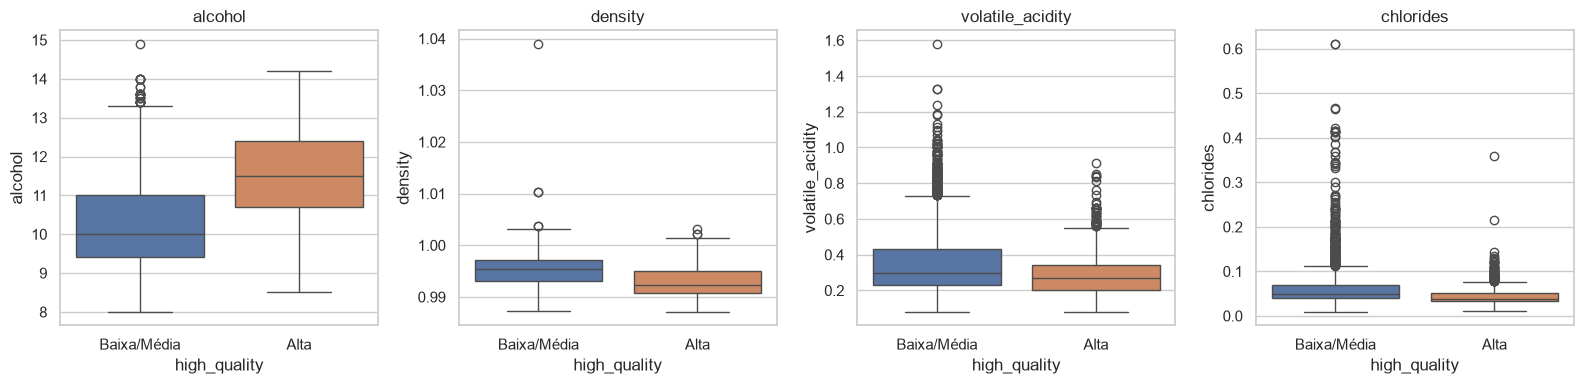

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["alcohol", "density", "volatile_acidity", "chlorides"]):
    sns.boxplot(data=df, x="high_quality", y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_xticklabels(["Baixa/Média", "Alta"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{RESULTS}/04_boxplots_top_features.png", dpi=150)
plt.show()

## Resumo da EDA (insumo para a apresentação executiva)

- Dataset limpo (sem nulos), mas com 18,1% de duplicatas a remover antes da
  modelagem.
- Classes desbalanceadas (~80/20) - decide a escolha de métricas e a
  necessidade de ponderar classes no treino.
- `alcohol`, `density`, `volatile_acidity` e `chlorides` são as variáveis mais
  associadas à qualidade e serão o foco da interpretação dos modelos.
- `wine_type` carrega sinal (brancos têm quase o dobro da taxa de alta
  qualidade dos tintos) e será mantido como feature categórica.

In [10]:
summary = {
    "n_amostras": len(df),
    "pct_nulos": 0.0,
    "pct_duplicatas": round(df.duplicated().mean() * 100, 2),
    "pct_alta_qualidade": round(df["high_quality"].mean() * 100, 2),
    "pct_alta_qualidade_tinto": round(df.loc[df.wine_type == "red", "high_quality"].mean() * 100, 2),
    "pct_alta_qualidade_branco": round(df.loc[df.wine_type == "white", "high_quality"].mean() * 100, 2),
    "top_corr_feature": corr["high_quality"].drop(["high_quality", "quality"]).abs().idxmax(),
}
pd.Series(summary).to_csv(f"{RESULTS}/eda_summary.csv", header=["valor"])
summary

{'n_amostras': 6497,
 'pct_nulos': 0.0,
 'pct_duplicatas': np.float64(18.12),
 'pct_alta_qualidade': np.float64(19.66),
 'pct_alta_qualidade_tinto': np.float64(13.57),
 'pct_alta_qualidade_branco': np.float64(21.64),
 'top_corr_feature': 'alcohol'}